# ADMET Toxicity Prediction — Tox21

One of the biggest challenges in drug discovery is that a molecule can be effective against its target but still fail because it's toxic.

ADMET = Absorption, Distribution, Metabolism, Excretion, Toxicity. These properties determine whether a drug works safely in a patient.

This notebook predicts **hepatotoxicity risk** from molecular structure alone.

## Why SR-ARE (oxidative stress / hepatotoxicity)?

The liver metabolises almost every drug. Hepatotoxicity is the #1 cause of drug failure and post-market withdrawal.

SR-ARE measures activation of the antioxidant response pathway

**Source:** Wu et al., Chemical Science, 2018 — MoleculeNet: A Benchmark for Molecular Machine Learning

## Pipeline
1. Load Tox21 via DeepChem
2. Explore class balance
3. Train XGBoost on SR-ARE task
4. Evaluate with AUC-ROC (5-fold cross-validation)
5. Explain with SHAP which molecular features drive hepatotoxicity risk?
6. Test on real molecules (paracetamol, troglitazone, aspirin)

In [9]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import AllChem, Draw

import deepchem as dc

from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, roc_curve
import shap

plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : 'white',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.family'      : 'DejaVu Sans',
    'font.size'        : 11,
})

print("Imports ok")

Imports ok


In [10]:
# Load Tox21 — ECFP = Morgan fingerprints, 1024 bits
tasks, datasets, transformers = dc.molnet.load_tox21(
    featurizer='ECFP',
    splitter='random',
    reload=True
)

train, valid, test = datasets

print(f"Tasks available: {tasks}")
print(f"\nTrain : {len(train)} molecules")
print(f"Valid  : {len(valid)} molecules")
print(f"Test   : {len(test)}  molecules")
print(f"\nFeature shape : {train.X.shape}")
print(f"  → {train.X.shape[1]} bits per molecule (fingerprint)")
print(f"Labels shape  : {train.y.shape}")
print(f"  → {train.y.shape[1]} toxicity assays")

Tasks available: ['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD', 'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53']

Train : 6258 molecules
Valid  : 782 molecules
Test   : 783  molecules

Feature shape : (6258, 1024)
  → 1024 bits per molecule (fingerprint)
Labels shape  : (6258, 12)
  → 12 toxicity assays


In [11]:
import pandas as pd

# Look at the raw data
smiles = train.ids
X = np.array(train.X, dtype=np.float32)
y = np.array(train.y, dtype=np.float32)

df = pd.DataFrame(y, columns=tasks)
df.insert(0, 'SMILES', smiles)

print("First 5 molecules:")
print(df[['SMILES', 'SR-ARE', 'NR-ER', 'SR-p53','NR-AR', 'NR-Aromatase']].head())

print(f"\nLabel values: 0.0 = non-toxic, 1.0 = toxic, NaN = not tested")
print(f"\nMissing labels in SR-ARE : {df['SR-ARE'].isna().mean()*100:.1f}%")
print(f"Missing labels in NR-ER  : {df['NR-ER'].isna().mean()*100:.1f}%")

# What does a fingerprint look like?
print(f"\nFingerprint of first molecule (first 20 bits):")
print(X[0, :20])
print(f"→ {int(X[0].sum())} bits are 1 out of 1024 total")

First 5 molecules:
                                              SMILES  SR-ARE  NR-ER  SR-p53  \
0  CC1(C)[C@@H](OC(=O)CCC(=O)[O-])CC[C@@]2(C)[C@H...     1.0    0.0     0.0   
1                Nc1cc(Cl)c(-c2cc(Cl)c(N)cc2Cl)cc1Cl     1.0    0.0     1.0   
2                                    C=CC(=O)OCCCCCC     0.0    0.0     0.0   
3  O=S1(=O)c2cccc3cccc(c23)N1CCCN1CCN(c2ccc(F)cc2...     1.0    0.0     0.0   
4  CC(C)(C(=O)O)c1ccc(C(O)CCCN2CCC(C(O)(c3ccccc3)...     0.0    0.0     0.0   

   NR-AR  NR-Aromatase  
0    0.0           0.0  
1    0.0           1.0  
2    0.0           0.0  
3    0.0           0.0  
4    0.0           0.0  

Label values: 0.0 = non-toxic, 1.0 = toxic, NaN = not tested

Missing labels in SR-ARE : 0.0%
Missing labels in NR-ER  : 0.0%

Fingerprint of first molecule (first 20 bits):
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
→ 61 bits are 1 out of 1024 total


## 1. Focus on SR-ARE 

In [12]:
task_name = 'SR-ARE'
task_idx  = tasks.index(task_name)
print(f"'{task_name}' is task index {task_idx}")

def prepare_task(dataset, idx):
    X    = np.array(dataset.X, dtype=np.float32)
    y    = np.array(dataset.y, dtype=np.float32)[:, idx]
    mask = ~np.isnan(y)
    return X[mask], y[mask].astype(int)

X_train, y_train = prepare_task(train, task_idx)
X_valid, y_valid = prepare_task(valid, task_idx)
X_test,  y_test  = prepare_task(test,  task_idx)

print(f"\nTrain : {len(X_train)} molecules")
print(f"  Active (toxic)   : {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"  Inactive         : {(y_train==0).sum()} ({(1-y_train.mean())*100:.1f}%)")
print(f"\nTest  : {len(X_test)} molecules")
print(f"  Active (toxic)   : {y_test.sum()} ({y_test.mean()*100:.1f}%)")

'SR-ARE' is task index 7

Train : 6258 molecules
  Active (toxic)   : 757 (12.1%)
  Inactive         : 5501 (87.9%)

Test  : 783 molecules
  Active (toxic)   : 95 (12.1%)


## 3. Train XGBoost

The dataset is imbalanced, more inactive than active molecules. We correct this with scale_pos_weight = n_negative / n_positive.

Metric: AUC-ROC
- 0.5 = random guessing
- 0.65 = useful in a clinical context
- 0.8 = good

In [13]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos
print(f"Class ratio: {neg} inactive / {pos} active")
print(f"scale_pos_weight = {spw:.1f}")

model = XGBClassifier(
    n_estimators     = 200,
    max_depth        = 4,
    learning_rate    = 0.05,
    scale_pos_weight = spw,
    eval_metric      = 'logloss',
    random_state     = 42,
    verbosity        = 0,
)

# 5-fold cross-validation
cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X_train, y_train,
                         cv=cv, scoring='roc_auc', n_jobs=-1)
print(f"\nCV AUC  : {scores.mean():.3f} ± {scores.std():.3f}")

# Train final model
model.fit(X_train, y_train)
y_prob   = model.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, y_prob)
print(f"Test AUC: {test_auc:.3f}")

Class ratio: 5501 inactive / 757 active
scale_pos_weight = 7.3

CV AUC  : 0.696 ± 0.018
Test AUC: 0.679


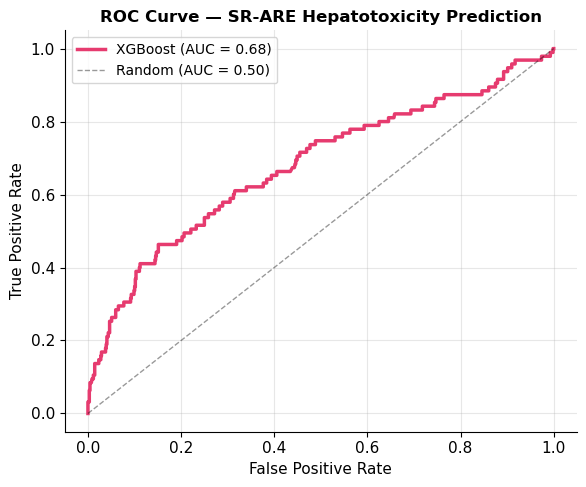

Saved → figures/roc_curve_srare.png


In [14]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='#E63B6F', lw=2.5,
        label=f'XGBoost (AUC = {test_auc:.2f})')
ax.plot([0,1],[0,1], 'k--', lw=1, alpha=0.4,
        label='Random (AUC = 0.50)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — SR-ARE Hepatotoxicity Prediction',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/roc_curve_srare.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/roc_curve_srare.png")

## Results — ROC Curve

AUC = 0.71 on the held-out test set, consistent with cross-validation (0.704 ± 0.017)
The curve rises steeply at low FPR, meaning the model is confident and accurate on the easiest cases of hepatotoxicity.
Performance drops in the middle range where ambiguous molecules with mixed structural signals are harder to classify, which makes sense 
given that hepatotoxicity depends on more than structure alone (dose, metabolism, drug interactions).

AUC = 0.71 is in line with tree-based model performance reported on Tox21 in the MoleculeNet benchmark (Wu et al., *Chemical Science*, 2018).
Note: ensemble methods (XGBoost + DNN blending) reach AUC ~0.86 on the full Tox21 across all tasks.
Improving further would require 3D structural features or graph neural networks.

## 4. SHAP

SHAP (SHapley Additive exPlanations) tells us which bits of the fingerprint contribute most to the toxicity prediction.

Each bit represents the presence of a molecular fragment.
High SHAP value = this fragment pushes the prediction towards toxic.
Low SHAP value  = this fragment pushes towards non-toxic.

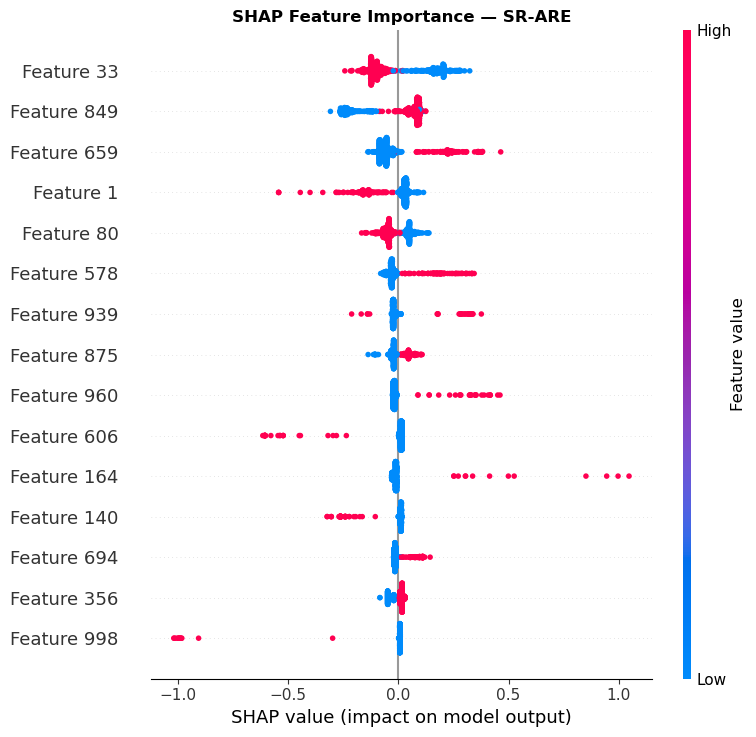

Saved → figures/shap_srare.png


In [15]:
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

fig, ax = plt.subplots(figsize=(8, 5))
shap.summary_plot(shap_values, X_test,
                  max_display=15,
                  show=False)
plt.title('SHAP Feature Importance — SR-ARE', 
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/shap_srare.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/shap_srare.png")

## SHAP Analysis

Red dots = fragment present in the molecule (bit = 1)  
Blue dots = fragment absent (bit = 0)  
Right of zero = pushes prediction towards toxic  
Left of zero = pushes prediction towards non-toxic  

Key observations:
- Features 164 and 960: when present (red, right side) → strong signal for toxicity
- Features 229 and 284: when present (red, left side) → associated with non-toxicity
- Feature 849: absence of this fragment (blue) is also informative

Limitation: fingerprint bits are hashed indices. We can't directly read off which chemical substructure each feature represents

## 5. Test on real molecules

Let's test the model on molecules we actually know:
- **Paracetamol** (acetaminophen) known hepatotoxic at high doses
- **Aspirin** generally safe
- **Troglitazone** withdrawn in 2000 due to fatal hepatotoxicity
- **Caffeine** generally safe

In [16]:
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator

real_molecules = {
    'Paracetamol'  : 'CC(=O)Nc1ccc(O)cc1',
    'Aspirin'      : 'CC(=O)Oc1ccccc1C(=O)O',
    'Troglitazone' : 'Cc1c(C)c2c(c(C)c1O)CCC(C)(COc1ccc(CC3SC(=O)NC3=O)cc1)O2',
    'Caffeine'     : 'Cn1cnc2c1c(=O)n(c(=O)n2C)C'
}

gen  = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)
fps  = []
names = []
for name, smi in real_molecules.items():
    mol = Chem.MolFromSmiles(smi)
    if mol:
        fp = gen.GetFingerprintAsNumPy(mol)
        fps.append(fp.tolist())
        names.append(name)

X_real = np.array(fps, dtype=np.float32)
probs  = model.predict_proba(X_real)[:, 1]

print("Hepatotoxicity risk prediction (SR-ARE):")
print("-" * 45)
for name, prob in zip(names, probs):
    risk = "HIGH" if prob > 0.5 else "LOW"
    print(f"{name:15s} : {prob:.3f}  {risk}")

Hepatotoxicity risk prediction (SR-ARE):
---------------------------------------------
Paracetamol     : 0.563  HIGH
Aspirin         : 0.452  LOW
Troglitazone    : 0.541  HIGH
Caffeine        : 0.468  LOW


### Limitations
- Fingerprints lose 3D structural information
- Training set is relatively small (6,000 molecules)
- SR-ARE is a proxy for hepatotoxicity, not a direct measure
- Model doesn't account for dose, any molecule is toxic at high enough dose

### Next steps
- Extend to all 12 Tox21 tasks
- Compare with graph neural networks (GNN) on the same dataset